In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pickle
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import yaml

from neuralhydrology.modelzoo import get_model
from neuralhydrology.utils.config import Config
from neuralhydrology.modelzoo.cudalstm import CudaLSTM
from neuralhydrology.modelzoo.customlstm import CustomLSTM

In [2]:
# ------- Paths -------
model_dir=Path('../CHIRPS_2.0/runs/gauge_and_chirps_precip_seq_270_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_0402_180903')
pickle_file_dir = model_dir / 'validation' / 'model_epoch030' / 'validation_results.p'
pt_file_dir = model_dir / 'model_epoch030.pt'
optimizer_file_dir = model_dir / 'optimizer_state_epoch030.pt'
scaler_path = model_dir / "train_data" / "train_data_scaler.yml"

In [3]:
pt_data = torch.load(pt_file_dir,weights_only=True)
# pt_data

In [4]:
cfg = Config(model_dir / "config.yml")

In [5]:
optimized_model = CudaLSTM(cfg)
# print(optimized_model)

state_dict = torch.load(pt_file_dir)

optimized_model.load_state_dict(state_dict)
optimized_model.eval()

/tmp/ipykernel_3988/2693144925.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pt_file_dir)


CudaLSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (lstm): LSTM(16, 256)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

In [6]:
custom_lstm = CustomLSTM(cfg=cfg)

In [7]:
custom_lstm.copy_weights(optimized_model)

In [8]:
custom_lstm.eval()

CustomLSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (cell): _LSTMCell()
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

In [9]:
# SCALER

with open(scaler_path, "r") as f:
    scaler = yaml.safe_load(f)

In [10]:
# LOADING ATTRIBUTES
attributes_file = Path("../CHIRPS_2.0/filtered_data_gauge_and_CHIRPS/attributes/attributes.csv")

df_attr = pd.read_csv(attributes_file, index_col=0)
df_attr.head()

,slope_mean,p_mean,aridity,gauge_name,pet_mean,high_prec_dur,silt_frac,area_gages2,frac_snow,high_prec_freq,low_prec_dur,sand_frac,elev_mean,clay_frac,low_prec_freq
gauge_id,,,,,,,,,,,,,,,
CAMELS_UY_10,12.725907,3.915340,0.717773,Paso Mazangano,2.810326,1.203846,23.706791,6530.808541,0.0,0.064271,4.354260,46.015110,169.307582,30.243464,0.664613
CAMELS_UY_7,15.561201,3.970856,0.716361,Paso de Coelho,2.844567,1.221795,24.611382,2419.341041,0.0,0.065229,4.570572,46.167766,175.073007,29.245498,0.678234
CAMELS_UY_12,19.234042,3.411160,0.787933,Sarandi del Yi,2.687766,1.213033,22.247986,1381.247863,0.0,0.066256,4.813197,51.963862,198.932640,25.767853,0.708966
CAMELS_UY_8,14.357646,3.922811,0.712604,Paso de las Toscas,2.795410,1.232258,22.190911,970.932984,0.0,0.065366,4.561788,47.650490,151.682992,29.976673,0.684736
CAMELS_UY_15,12.119889,3.660062,0.817819,Paso de las Piedras (R3),2.993270,1.234536,25.837488,791.650467,0.0,0.065572,5.027247,43.814931,79.279041,30.758116,0.719849


In [11]:
# --- Define the features your model uses ---
static_features = [
    "elev_mean",
    "slope_mean",
    "area_gages2",
    "sand_frac",
    "silt_frac",
    "clay_frac",
    "p_mean",
    "pet_mean",
    "aridity",
    "high_prec_dur",
    "low_prec_dur"
]

In [12]:
# Ensure the index is a string
df_attr.index = df_attr.index.astype(str)

# Select your basin
basin = "CAMELS_UY_6"

# static_values
static_values = df_attr.loc[basin, static_features].to_numpy(dtype=np.float32)

attr_means = np.array([scaler["attribute_means"][k] for k in static_features], dtype=np.float32)
attr_stds  = np.array([scaler["attribute_stds"][k]  for k in static_features], dtype=np.float32)

static_norm = (static_values - attr_means) / attr_stds
static_tensor = torch.tensor(static_norm).unsqueeze(0)  # [1, n_static]

print(static_tensor.shape)
print(static_tensor)

torch.Size([1, 11])
tensor([[ 0.4283,  0.4591,  1.3361,  0.5230,  0.2142, -0.7414,  0.5612,  0.5338,
         -0.2160, -0.5806, -0.1276]])


In [13]:
# DYNAMIC INPUTS

def norm_dyn(tensor, varname):
    center = scaler["xarray_feature_center"]["data_vars"][varname]["data"]
    scale  = scaler["xarray_feature_scale"]["data_vars"][varname]["data"]
    center = torch.tensor(center, dtype=tensor.dtype, device=tensor.device)
    scale  = torch.tensor(scale,  dtype=tensor.dtype, device=tensor.device)
    return (tensor - center) / scale

In [14]:
ts_file = Path("../CHIRPS_2.0/filtered_data_gauge_and_CHIRPS/time_series") / f"{basin}.nc"

ds = xr.open_dataset(ts_file)
print(ds)

<xarray.Dataset> Size: 408kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge data used where available


In [15]:
dynamic_vars = ["QObs_mm_d","prcp_mm_day","srad_W_m2","tmax_C","tmin_C","prcp_chirps_mm_day"]

In [16]:
# --- Convert xarray to DataFrame and sort by date ---
df_dyn = ds[dynamic_vars].to_dataframe().sort_index()
df_dyn

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1989-01-01,NaN,1.000000,255.250000,33.220001,20.340000,0.000000
1989-01-02,NaN,0.000000,286.890015,35.230000,22.540001,0.000000
1989-01-03,NaN,0.000000,303.209991,34.570000,20.590000,0.000000
1989-01-04,NaN,0.000000,301.910004,36.049999,22.180000,0.000000
1989-01-05,NaN,0.000000,298.950012,35.790001,22.730000,0.000000
...,...,...,...,...,...,...
2019-12-27,0.275373,0.000000,264.109985,35.290001,21.980000,0.000000
2019-12-28,0.268004,26.333334,237.059998,35.470001,23.469999,5.839116
2019-12-29,0.272781,0.000000,283.500000,34.619999,22.440001,0.776535


In [17]:
t0_date = pd.to_datetime("2008-10-01")

In [18]:
# seq_length = 270  # same as your model’s training
seq_length = 3285 # 9 years

# Find the index of t0
t0_idx = df_dyn.index.get_loc(t0_date)

# Slice the dynamic data for the sequence before t0
start_idx = t0_idx - seq_length + 1  # inclusive
history_df = df_dyn.iloc[start_idx : t0_idx + 1][dynamic_vars]
history_df


,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1999-10-05,0.506392,0.000000,170.339996,16.889999,5.55,5.947970
1999-10-06,0.489719,6.333333,176.089996,22.010000,10.37,0.000000
1999-10-07,0.483109,15.000000,36.860001,16.660000,14.12,8.487308
1999-10-08,0.483816,0.000000,62.470001,17.840000,11.30,0.000000
1999-10-09,0.509847,0.000000,130.600006,17.080000,9.59,0.000000
...,...,...,...,...,...,...
2008-09-27,0.294101,0.000000,195.029999,22.830000,12.50,0.000000
2008-09-28,0.293459,5.333333,212.270004,24.540001,12.43,0.000000
2008-09-29,0.281799,16.666666,51.830002,18.910000,14.91,33.052341


In [19]:
# --- Convert to tensor ---
historical_dynamic_tensor = torch.tensor(history_df.values.astype(np.float32)).unsqueeze(0)
print(historical_dynamic_tensor.shape)  # should be [1, 270, 4]

torch.Size([1, 3285, 6])


In [20]:
# historical_dynamic_tensor: [1, 270, 6] as you already computed
x_prcp      = historical_dynamic_tensor[..., 1:2]
x_srad      = historical_dynamic_tensor[..., 2:3]
x_tmax      = historical_dynamic_tensor[..., 3:4]
x_tmin      = historical_dynamic_tensor[..., 4:5]
x_prcp_ch   = historical_dynamic_tensor[..., 5:6]

x_prcp_norm    = norm_dyn(x_prcp,    "prcp_mm_day")
x_srad_norm    = norm_dyn(x_srad,    "srad_W_m2")
x_tmax_norm    = norm_dyn(x_tmax,    "tmax_C")
x_tmin_norm    = norm_dyn(x_tmin,    "tmin_C")
x_prcp_ch_norm = norm_dyn(x_prcp_ch, "prcp_chirps_mm_day")

history_inputs = {
    "x_d": {
        "prcp_mm_day":        x_prcp_norm,
        "srad_W_m2":          x_srad_norm,
        "tmax_C":             x_tmax_norm,
        "tmin_C":             x_tmin_norm,
        "prcp_chirps_mm_day": x_prcp_ch_norm,
    },
    "x_s": static_tensor
}

In [21]:
history_inputs = {
    "x_d": {k: v for k, v in history_inputs["x_d"].items()},
    "x_s": history_inputs["x_s"]
}

with torch.no_grad():
    out = custom_lstm(history_inputs)

h0 = out["h_n"]
c0 = out["c_n"]
y_hat = out["y_hat"]

print("h0 shape:", h0.shape)
print("c0 shape:", c0.shape)
print("Predictions shape:", y_hat.shape)
print("First 10 predictions (normalized):", y_hat[0, :10, 0])

h0 shape: torch.Size([1, 3285, 256])
c0 shape: torch.Size([1, 3285, 256])
Predictions shape: torch.Size([1, 3285, 1])
First 10 predictions (normalized): tensor([-0.0732, -0.0541,  0.2439,  0.3108,  0.2407,  0.1329, -0.0032, -0.0077,
         0.3567,  1.2187])


In [22]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

q_center = torch.tensor(q_center, dtype=y_hat.dtype, device=y_hat.device)
q_scale  = torch.tensor(q_scale,  dtype=y_hat.dtype, device=y_hat.device)

y_hat_denorm = y_hat * q_scale + q_center
print("First 10 predictions (mm/d):", y_hat_denorm[0, :10, 0].cpu().numpy())

First 10 predictions (mm/d): [1.3230846 1.3960967 2.535789  2.791531  2.5236723 2.1114364 1.5906057
 1.5734937 2.9672537 6.2633696]


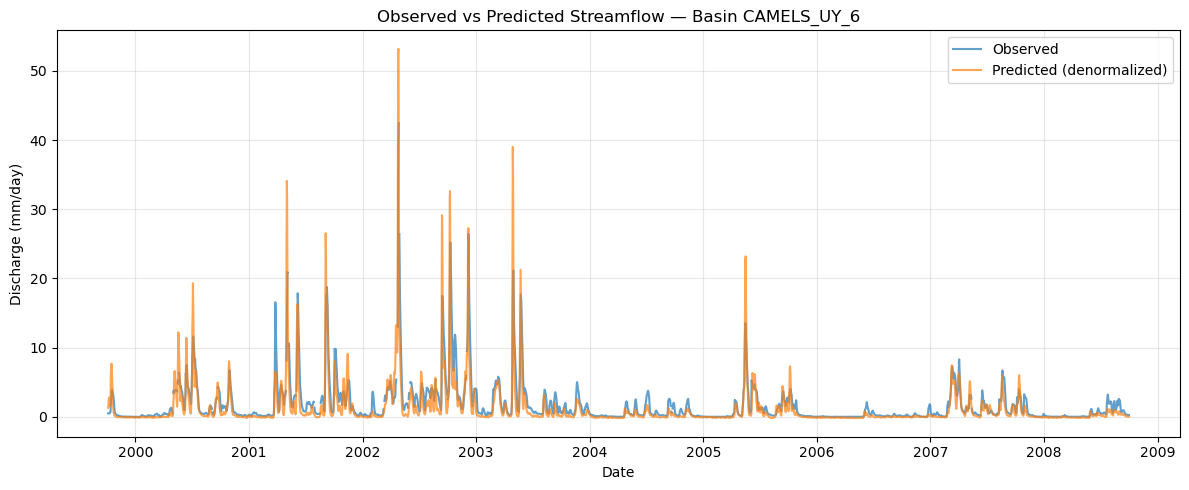

In [23]:
# --- Extract numpy arrays ---
pred = y_hat_denorm[0, :, 0].cpu().numpy()     # [270]
obs  = history_df["QObs_mm_d"].values          # [270]
dates = history_df.index                       # DatetimeIndex

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(dates, obs, label="Observed", alpha=0.7)
plt.plot(dates, pred, label="Predicted (denormalized)", alpha=0.7)

plt.title(f"Observed vs Predicted Streamflow — Basin {basin}")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
# now i am going to train using the 1999-2008, extract the last h and c, and feed these as h_0 and c_0 to the 1989-1999 period

In [39]:
spinup_start = pd.to_datetime("1999-10-01")
spinup_end   = pd.to_datetime("2008-09-30")

spinup_df = df_dyn.loc[spinup_start:spinup_end][dynamic_vars]
spinup_df

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1999-10-01,0.260440,26.666666,30.719999,14.340000,8.50,18.714029
1999-10-02,0.283290,0.000000,185.690002,13.320000,5.74,0.000000
1999-10-03,0.345822,0.000000,192.080002,10.760000,2.47,0.000000
1999-10-04,0.463125,0.000000,188.330002,12.800000,1.98,0.000000
1999-10-05,0.506392,0.000000,170.339996,16.889999,5.55,5.947970
...,...,...,...,...,...,...
2008-09-26,0.297739,0.000000,199.339996,22.030001,11.67,0.000000
2008-09-27,0.294101,0.000000,195.029999,22.830000,12.50,0.000000
2008-09-28,0.293459,5.333333,212.270004,24.540001,12.43,0.000000


In [40]:
# --- Convert to tensor ---
spinup_tensor = torch.tensor(spinup_df.values.astype(np.float32)).unsqueeze(0)
print(spinup_tensor.shape)  # should be [1, 270, 4]

torch.Size([1, 3288, 6])


In [41]:
# historical_dynamic_tensor: [1, 270, 6] as you already computed
x_prcp      = spinup_tensor[..., 1:2]
x_srad      = spinup_tensor[..., 2:3]
x_tmax      = spinup_tensor[..., 3:4]
x_tmin      = spinup_tensor[..., 4:5]
x_prcp_ch   = spinup_tensor[..., 5:6]

x_prcp_norm    = norm_dyn(x_prcp,    "prcp_mm_day")
x_srad_norm    = norm_dyn(x_srad,    "srad_W_m2")
x_tmax_norm    = norm_dyn(x_tmax,    "tmax_C")
x_tmin_norm    = norm_dyn(x_tmin,    "tmin_C")
x_prcp_ch_norm = norm_dyn(x_prcp_ch, "prcp_chirps_mm_day")

spinup_inputs = {
    "x_d": {
        "prcp_mm_day":        x_prcp_norm,
        "srad_W_m2":          x_srad_norm,
        "tmax_C":             x_tmax_norm,
        "tmin_C":             x_tmin_norm,
        "prcp_chirps_mm_day": x_prcp_ch_norm,
    },
    "x_s": static_tensor
}

In [45]:
spinup_inputs = {
    "x_d": {k: v for k, v in spinup_inputs["x_d"].items()},
    "x_s": spinup_inputs["x_s"]
}

with torch.no_grad():
    out = custom_lstm(spinup_inputs)

# h0 = out["h_n"]
# c0 = out["c_n"]
h_val = out["h_n"][:, -1, :]
c_val = out["c_n"][:, -1, :]
y_hat = out["y_hat"]

print("h0 shape:", h0.shape)
print("c0 shape:", c0.shape)
print("Predictions shape:", y_hat.shape)
print("First 10 predictions (normalized):", y_hat[0, :10, 0])

h0 shape: torch.Size([1, 3288, 256])
c0 shape: torch.Size([1, 3288, 256])
Predictions shape: torch.Size([1, 3288, 1])
First 10 predictions (normalized): tensor([0.9045, 1.2295, 1.1294, 0.9746, 0.8343, 0.6769, 0.5396, 0.5039, 0.3177,
        0.1379])


In [46]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

q_center = torch.tensor(q_center, dtype=y_hat.dtype, device=y_hat.device)
q_scale  = torch.tensor(q_scale,  dtype=y_hat.dtype, device=y_hat.device)

y_hat_denorm = y_hat * q_scale + q_center
print("First 10 predictions (mm/d):", y_hat_denorm[0, :10, 0].cpu().numpy())

First 10 predictions (mm/d): [5.062134  6.3047457 5.921891  5.330195  4.793325  4.19143   3.666688
 3.5298915 2.818028  2.1302419]


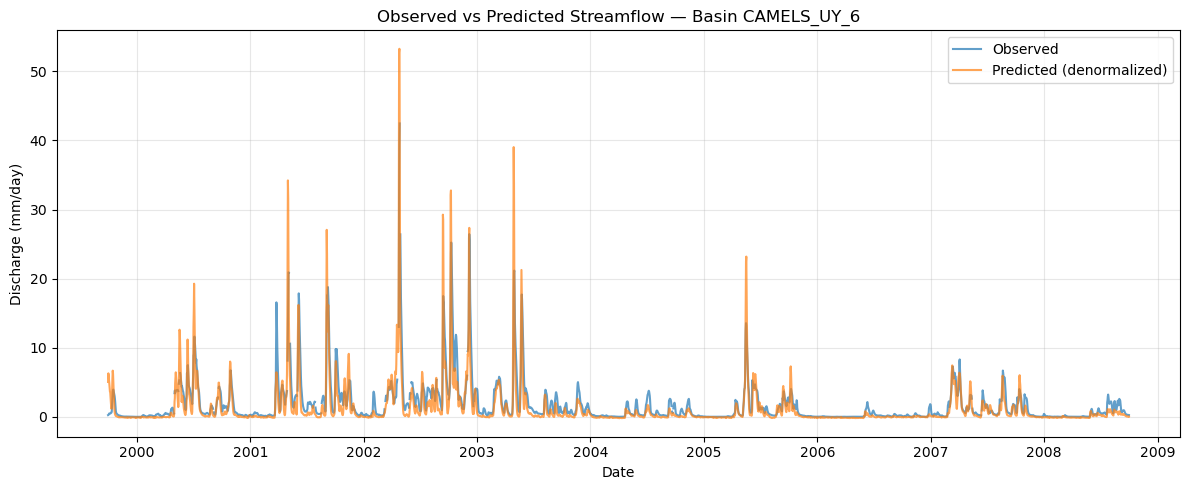

In [47]:
# --- Extract numpy arrays ---
pred = y_hat_denorm[0, :, 0].cpu().numpy()     # [270]
obs  = spinup_df["QObs_mm_d"].values          # [270]
dates = spinup_df.index                       # DatetimeIndex

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(dates, obs, label="Observed", alpha=0.7)
plt.plot(dates, pred, label="Predicted (denormalized)", alpha=0.7)

plt.title(f"Observed vs Predicted Streamflow — Basin {basin}")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [48]:
val_start = pd.to_datetime("1989-10-01")
val_end   = pd.to_datetime("1999-09-30")

val_df = df_dyn.loc[val_start:val_end][dynamic_vars]
val_df

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1989-10-01,0.225680,0.000000,232.889999,23.690001,8.28,0.000000
1989-10-02,0.202502,0.000000,176.169998,25.469999,12.65,1.398940
1989-10-03,0.183512,0.000000,241.570007,21.750000,12.05,4.517782
1989-10-04,0.165661,0.000000,249.320007,21.420000,7.78,0.000000
1989-10-05,0.153751,0.000000,228.300003,24.110001,8.56,0.000000
...,...,...,...,...,...,...
1999-09-26,0.369995,0.000000,125.419998,20.730000,13.26,5.413037
1999-09-27,0.340993,0.000000,199.690002,20.500000,10.88,0.037418
1999-09-28,0.302948,0.333333,126.580002,23.100000,11.93,0.000000


In [49]:
# --- Convert to tensor ---
val_tensor = torch.tensor(val_df.values.astype(np.float32)).unsqueeze(0)
print(val_tensor.shape)  # should be [1, 270, 4]

torch.Size([1, 3652, 6])


In [50]:
# historical_dynamic_tensor: [1, 270, 6] as you already computed
x_prcp      = val_tensor[..., 1:2]
x_srad      = val_tensor[..., 2:3]
x_tmax      = val_tensor[..., 3:4]
x_tmin      = val_tensor[..., 4:5]
x_prcp_ch   = val_tensor[..., 5:6]

x_prcp_norm    = norm_dyn(x_prcp,    "prcp_mm_day")
x_srad_norm    = norm_dyn(x_srad,    "srad_W_m2")
x_tmax_norm    = norm_dyn(x_tmax,    "tmax_C")
x_tmin_norm    = norm_dyn(x_tmin,    "tmin_C")
x_prcp_ch_norm = norm_dyn(x_prcp_ch, "prcp_chirps_mm_day")

val_inputs = {
    "x_d": {
        "prcp_mm_day":        x_prcp_norm,
        "srad_W_m2":          x_srad_norm,
        "tmax_C":             x_tmax_norm,
        "tmin_C":             x_tmin_norm,
        "prcp_chirps_mm_day": x_prcp_ch_norm,
    },
    "x_s": static_tensor
}

In [51]:
val_inputs = {
    "x_d": {k: v for k, v in val_inputs["x_d"].items()},
    "x_s": val_inputs["x_s"]
}

with torch.no_grad():
    out = custom_lstm(val_inputs, h_0=h_val, c_0=c_val)

y_hat = out["y_hat"]

print("h0 shape:", h0.shape)
print("c0 shape:", c0.shape)
print("Predictions shape:", y_hat.shape)
print("First 10 predictions (normalized):", y_hat[0, :10, 0])

h0 shape: torch.Size([1, 3288, 256])
c0 shape: torch.Size([1, 3288, 256])
Predictions shape: torch.Size([1, 3652, 1])
First 10 predictions (normalized): tensor([-0.3944, -0.3938, -0.3945, -0.3942, -0.3971, -0.4029, -0.4058, -0.4110,
        -0.4073, -0.4077])


In [52]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

q_center = torch.tensor(q_center, dtype=y_hat.dtype, device=y_hat.device)
q_scale  = torch.tensor(q_scale,  dtype=y_hat.dtype, device=y_hat.device)

y_hat_denorm = y_hat * q_scale + q_center
print("First 10 predictions (mm/d):", y_hat_denorm[0, :10, 0].cpu().numpy())

First 10 predictions (mm/d): [0.0947243  0.09694076 0.09447467 0.095608   0.08430934 0.06236196
 0.0513432  0.03130484 0.04537237 0.04381382]


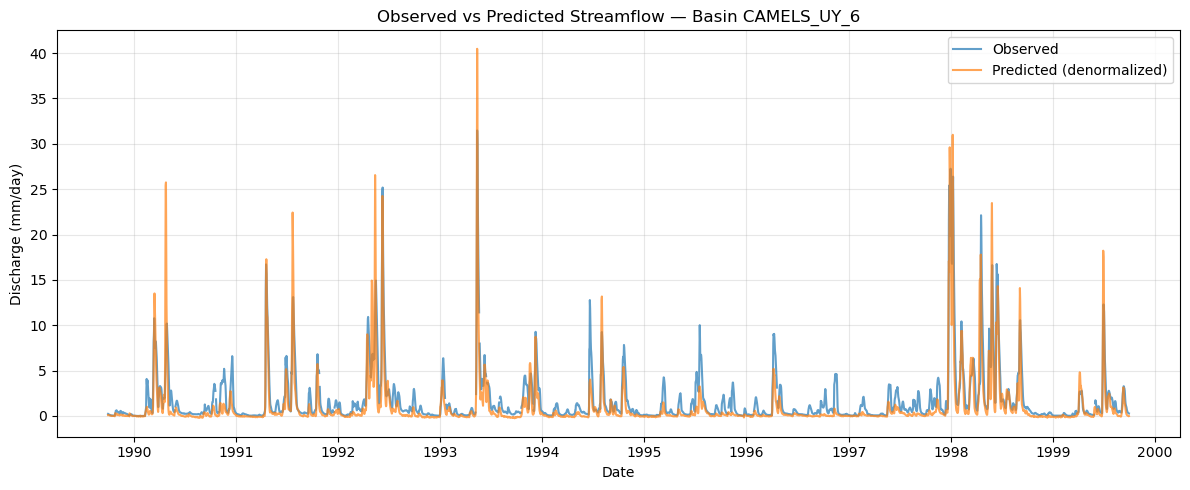

In [53]:
# --- Extract numpy arrays ---
pred = y_hat_denorm[0, :, 0].cpu().numpy()     # [270]
obs  = val_df["QObs_mm_d"].values          # [270]
dates = val_df.index                       # DatetimeIndex

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(dates, obs, label="Observed", alpha=0.7)
plt.plot(dates, pred, label="Predicted (denormalized)", alpha=0.7)

plt.title(f"Observed vs Predicted Streamflow — Basin {basin}")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# NOW DOING THE MODEL SPIN-UP

In [25]:
# spinup_start = pd.to_datetime("1989-10-01")
# spinup_end   = t0_date

spinup_start = pd.to_datetime("1989-01-05")
spinup_end   = pd.to_datetime("1999-09-30")

spinup_df = df_dyn.loc[spinup_start:spinup_end][dynamic_vars]
spinup_df

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1989-01-05,NaN,0.000000,298.950012,35.790001,22.730000,0.000000
1989-01-06,NaN,0.000000,149.240005,30.840000,23.270000,0.443522
1989-01-07,NaN,2.666667,255.960007,32.889999,22.809999,0.504765
1989-01-08,NaN,0.000000,229.960007,31.110001,21.860001,0.000000
1989-01-09,NaN,0.000000,303.380005,30.770000,17.480000,0.000000
...,...,...,...,...,...,...
1999-09-26,0.369995,0.000000,125.419998,20.730000,13.260000,5.413037
1999-09-27,0.340993,0.000000,199.690002,20.500000,10.880000,0.037418
1999-09-28,0.302948,0.333333,126.580002,23.100000,11.930000,0.000000


In [26]:
spinup_tensor = torch.tensor(
    spinup_df.values.astype(np.float32)
).unsqueeze(0)  # [1, T, features]

In [27]:
x_prcp      = spinup_tensor[..., 1:2]
x_srad      = spinup_tensor[..., 2:3]
x_tmax      = spinup_tensor[..., 3:4]
x_tmin      = spinup_tensor[..., 4:5]
x_prcp_ch   = spinup_tensor[..., 5:6]

spinup_inputs = {
    "prcp_mm_day":        norm_dyn(x_prcp, "prcp_mm_day"),
    "srad_W_m2":          norm_dyn(x_srad, "srad_W_m2"),
    "tmax_C":             norm_dyn(x_tmax, "tmax_C"),
    "tmin_C":             norm_dyn(x_tmin, "tmin_C"),
    "prcp_chirps_mm_day": norm_dyn(x_prcp_ch, "prcp_chirps_mm_day"),
}


In [28]:
seq_length = cfg.seq_length
T = spinup_tensor.shape[1]

h = None
c = None

predictions = []
pred_dates = []

dates = spinup_df.index

with torch.no_grad():

    for start in range(0, T - seq_length + 1):

        end = start + seq_length

        window_inputs = {
            "x_d": {k: v[:, start:end, :]
                    for k, v in spinup_inputs.items()},
            "x_s": static_tensor
        }

        # if h is not None:
        #     window_inputs["h_0"] = h
        #     window_inputs["c_0"] = c

        out = custom_lstm(window_inputs, h_0=h, c_0=c)

        # h = out["h_n"]
        # print(h)
        # print(out["h_n"].shape)
        # c = out["c_n"]
        # print(c)
        # print(out["c_n"].shape)

        h = out["h_n"][:, -1, :]
        c = out["c_n"][:, -1, :]

        # Extract LAST timestep prediction
        y_pred = out["y_hat"][:, -1, :]

        predictions.append(y_pred.cpu().numpy().squeeze())

        pred_dates.append(dates[end - 1])


In [33]:
h

tensor([[-3.2963e-02, -8.3980e-02,  5.1993e-03,  6.0398e-02,  3.3291e-02,
         -1.4103e-02, -2.1594e-03, -4.5755e-02, -5.2559e-01,  4.9336e-01,
         -2.8757e-03,  4.2508e-03, -1.7104e-03,  1.5634e-02,  1.5283e-02,
          9.9880e-02,  2.6828e-01, -2.2584e-02,  2.0596e-01, -1.3091e-02,
          4.2513e-02, -2.1804e-02,  2.0984e-01,  6.7832e-02, -4.0851e-02,
         -6.5740e-01, -4.0315e-02, -2.1827e-02, -7.8603e-02,  7.0174e-01,
         -3.3343e-03,  1.6415e-01,  2.0426e-01, -1.1338e-01,  3.2839e-01,
          2.3213e-01,  5.3405e-02, -1.2933e-02,  1.2944e-01,  2.8864e-01,
         -1.0909e-01,  8.0833e-02, -3.9704e-02, -2.7342e-01,  4.6667e-01,
         -3.7038e-01,  2.5594e-03, -9.2200e-03,  1.2181e-01, -4.7076e-02,
          6.1764e-01, -2.9482e-01,  7.1714e-02, -7.2452e-01, -2.4508e-03,
          5.9449e-03, -5.5054e-01, -1.1842e-01, -6.1045e-01,  1.7743e-01,
         -5.3718e-02,  4.2582e-03,  5.5747e-02, -1.0549e-01,  7.3177e-02,
         -2.1298e-03, -1.7893e-01,  5.

In [29]:
predictions = np.array(predictions)
pred_dates = pd.to_datetime(pred_dates)

In [30]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

predictions = predictions * q_scale + q_center

In [31]:
obs = df_dyn.loc[pred_dates]["QObs_mm_d"].values


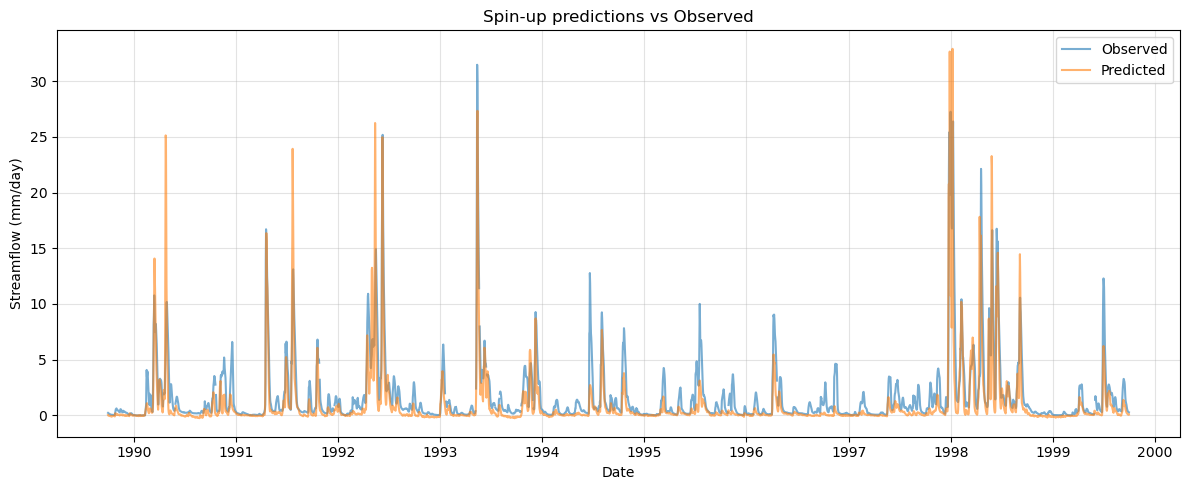

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(pred_dates, obs, label="Observed",alpha=0.6)
plt.plot(pred_dates, predictions, label="Predicted",alpha=0.6)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title("Spin-up predictions vs Observed")

plt.grid(True, alpha=0.35)
plt.tight_layout()

# # Save directly into run_out_dir (no subfolders)
# out_path = "hydrograph_CAMELS_UY_6_spinup.png"
# plt.savefig(out_path, dpi=200)
# plt.close()

plt.show()

In [24]:
# TRYING TO REPLICATE VALIDATION RESULTS

In [25]:
spinup_start = pd.to_datetime("1999-10-01")
spinup_end   = pd.to_datetime("2008-09-30")

spinup_df = df_dyn.loc[spinup_start:spinup_end][dynamic_vars]
spinup_df

,QObs_mm_d,prcp_mm_day,srad_W_m2,tmax_C,tmin_C,prcp_chirps_mm_day
date,,,,,,
1999-10-01,0.260440,26.666666,30.719999,14.340000,8.50,18.714029
1999-10-02,0.283290,0.000000,185.690002,13.320000,5.74,0.000000
1999-10-03,0.345822,0.000000,192.080002,10.760000,2.47,0.000000
1999-10-04,0.463125,0.000000,188.330002,12.800000,1.98,0.000000
1999-10-05,0.506392,0.000000,170.339996,16.889999,5.55,5.947970
...,...,...,...,...,...,...
2008-09-26,0.297739,0.000000,199.339996,22.030001,11.67,0.000000
2008-09-27,0.294101,0.000000,195.029999,22.830000,12.50,0.000000
2008-09-28,0.293459,5.333333,212.270004,24.540001,12.43,0.000000


In [26]:
spinup_tensor = torch.tensor(
    spinup_df.values.astype(np.float32)
).unsqueeze(0)  # [1, T, features]

x_prcp      = spinup_tensor[..., 1:2]
x_srad      = spinup_tensor[..., 2:3]
x_tmax      = spinup_tensor[..., 3:4]
x_tmin      = spinup_tensor[..., 4:5]
x_prcp_ch   = spinup_tensor[..., 5:6]

spinup_inputs = {
    "prcp_mm_day":        norm_dyn(x_prcp, "prcp_mm_day"),
    "srad_W_m2":          norm_dyn(x_srad, "srad_W_m2"),
    "tmax_C":             norm_dyn(x_tmax, "tmax_C"),
    "tmin_C":             norm_dyn(x_tmin, "tmin_C"),
    "prcp_chirps_mm_day": norm_dyn(x_prcp_ch, "prcp_chirps_mm_day"),
}

In [27]:
seq_length = cfg.seq_length
T = spinup_tensor.shape[1]

h = None
c = None

predictions = []
pred_dates = []

dates = spinup_df.index

with torch.no_grad():

    for start in range(0, T - seq_length + 1):

        end = start + seq_length

        window_inputs = {
            "x_d": {k: v[:, start:end, :]
                    for k, v in spinup_inputs.items()},
            "x_s": static_tensor
        }

        # if h is not None:
        #     window_inputs["h_n"] = h
        #     window_inputs["c_n"] = c

        out = custom_lstm(window_inputs,h_0=h, c_0=c)

        h = out["h_n"][:, -1, :]
        c = out["c_n"][:, -1, :]

        # Extract LAST timestep prediction
        y_pred = out["y_hat"][:, -1, :]

        predictions.append(y_pred.cpu().numpy().squeeze())

        pred_dates.append(dates[end - 1])


In [28]:
pred_start = pd.to_datetime("1989-10-01")
pred_end   = pd.to_datetime("1999-09-30")

# Include extra data for seq_length
full_start = pred_start - pd.Timedelta(days=seq_length-1)  # 1989-01-05
val_df = df_dyn.loc[full_start:pred_end][dynamic_vars]

val_tensor = torch.tensor(
    val_df.values.astype(np.float32)
).unsqueeze(0)  # [1, T_total, features]

x_prcp      = val_tensor[..., 1:2]
x_srad      = val_tensor[..., 2:3]
x_tmax      = val_tensor[..., 3:4]
x_tmin      = val_tensor[..., 4:5]
x_prcp_ch   = val_tensor[..., 5:6]

val_inputs = {
    "prcp_mm_day":        norm_dyn(x_prcp, "prcp_mm_day"),
    "srad_W_m2":          norm_dyn(x_srad, "srad_W_m2"),
    "tmax_C":             norm_dyn(x_tmax, "tmax_C"),
    "tmin_C":             norm_dyn(x_tmin, "tmin_C"),
    "prcp_chirps_mm_day": norm_dyn(x_prcp_ch, "prcp_chirps_mm_day"),
}


In [29]:
T_val = val_tensor.shape[1]
dates_val = val_df.index[seq_length-1:]  # skip initial seq_length -1

predictions_val = []

with torch.no_grad():
    h_val = h  # from spinup
    c_val = c

    for start in range(0, T_val - seq_length + 1):
        end = start + seq_length

        window_inputs = {
            "x_d": {k: v[:, start:end, :]
                    for k, v in val_inputs.items()},
            "x_s": static_tensor
        }

        # # Pass previous hidden/cell states
        # window_inputs["h_n"] = h_val
        # window_inputs["c_n"] = c_val

        out = custom_lstm(window_inputs, h_0=h_val, c_0=c_val)

        h_val = out["h_n"][:, -1, :]
        c_val = out["c_n"][:, -1, :]

        y_pred = out["y_hat"][:, -1, :]
        predictions_val.append(y_pred.cpu().numpy().squeeze())


In [30]:
predictions_val = np.array(predictions_val)
pred_dates_val = pd.to_datetime(dates_val)

In [31]:
q_center = scaler["xarray_feature_center"]["data_vars"]["QObs_mm_d"]["data"]
q_scale  = scaler["xarray_feature_scale"]["data_vars"]["QObs_mm_d"]["data"]

predictions_val = predictions_val * q_scale + q_center

In [32]:
obs_val = df_dyn.loc[pred_dates_val]["QObs_mm_d"].values


In [33]:
df_results = pd.DataFrame({
    "Date": pred_dates_val,
    "Predicted_Q": predictions_val,
    "Observed_Q": obs_val
}).set_index("Date")
df_results.head()

,Predicted_Q,Observed_Q
Date,,
1989-10-01,0.004918,0.225680
1989-10-02,-0.008839,0.202502
1989-10-03,-0.028021,0.183512
1989-10-04,-0.033570,0.165661
1989-10-05,-0.028745,0.153751


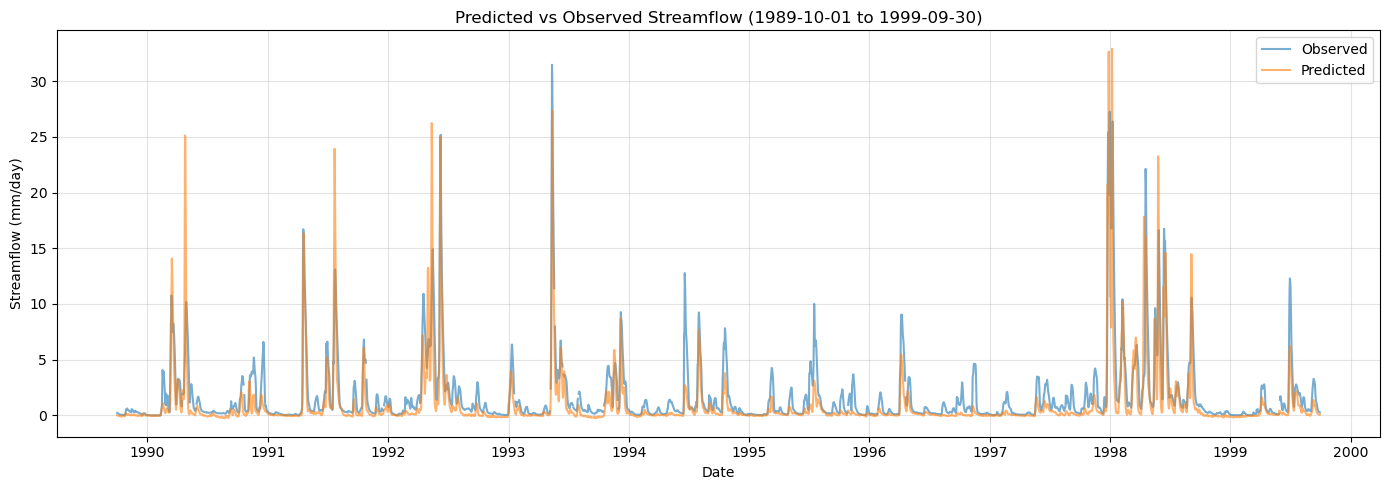

In [34]:
plt.figure(figsize=(14,5))
plt.plot(df_results.index, df_results["Observed_Q"], label="Observed", alpha=0.6)
plt.plot(df_results.index, df_results["Predicted_Q"], label="Predicted", alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title("Predicted vs Observed Streamflow (1989-10-01 to 1999-09-30)")
plt.legend()

plt.grid(True, alpha=0.35)
plt.tight_layout()

plt.show()